TypeError: imshow() missing 1 required positional argument: 'X'

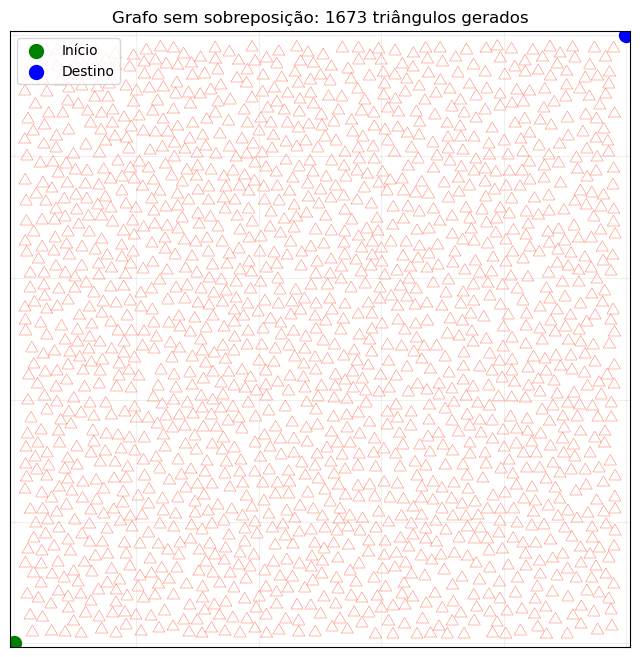

In [ ]:
import networkx as nx
import math
import random
import matplotlib.pyplot as plt

def vertice_no_triangulo(vertice, v1, v2, v3):
    def sinal(p1, p2, p3):
        return (p1[0] - p3[0]) * (p2[1] - p3[1]) - (p2[0] - p3[0]) * (p1[1] - p3[1])

    orientacao_aresta1 = sinal(vertice, v1, v2)
    orientacao_aresta2 = sinal(vertice, v2, v3)
    orientacao_aresta3 = sinal(vertice, v3, v1)

    tem_negativo = (orientacao_aresta1 < 0) or (orientacao_aresta2 < 0) or (orientacao_aresta3 < 0)
    tem_positivo = (orientacao_aresta1 > 0) or (orientacao_aresta2 > 0) or (orientacao_aresta3 > 0)

    return not (tem_negativo and tem_positivo)

def triangulos_colidem(tri1, tri2):
    for vertice in tri1:
        if vertice_no_triangulo(vertice, tri2[0], tri2[1], tri2[2]):
            return True
    for vertice in tri2:
        if vertice_no_triangulo(vertice, tri1[0], tri1[1], tri1[2]):
            return True
    return False

def segmentos_se_interceptam(p1, p2, p3, p4):
    """Verifica se o segmento p1p2 cruza p3p4 usando a fórmula do determinante"""
    def orientacao(a, b, c):
        val = (b[1] - a[1]) * (c[0] - b[0]) - (b[0] - a[0]) * (c[1] - b[1])
        if abs(val) < 1e-9: return 0  # Colinear
        return 1 if val > 0 else 2 # Horário ou Anti-horário

    o1 = orientacao(p1, p2, p3)
    o2 = orientacao(p1, p2, p4)
    o3 = orientacao(p3, p4, p1)
    o4 = orientacao(p3, p4, p2)

    # Caso geral: orientações diferentes
    if o1 != o2 and o3 != o4:
        return True
    return False

def aresta_livre(p_inicio, p_fim, obstaculos):
    """Verifica se a linha entre p_inicio e p_fim é válida"""
    # 1. Checa se a aresta passa 'por dentro' do triângulo pelo ponto médio
    p_medio = ((p_inicio[0] + p_fim[0]) / 2, (p_inicio[1] + p_fim[1]) / 2)
    
    for tri in obstaculos:
        # Se os dois pontos pertencem ao mesmo triângulo, não conectamos (conforme seu pedido)
        if p_inicio in tri and p_fim in tri:
            return False
            
        # Se o ponto médio está dentro de um triângulo, a aresta atravessa o interior
        if vertice_no_triangulo(p_medio, tri[0], tri[1], tri[2]):
            return False

        # 2. Checa interseção com as bordas de cada triângulo
        bordas = [(tri[0], tri[1]), (tri[1], tri[2]), (tri[2], tri[0])]
        for b1, b2 in bordas:
            # Ignora se a borda compartilha um dos pontos da nossa aresta
            if p_inicio == b1 or p_inicio == b2 or p_fim == b1 or p_fim == b2:
                continue
            if segmentos_se_interceptam(p_inicio, p_fim, b1, b2):
                return False
    return True

def criar_cenario(limite_x, limite_y, qtd_obstaculos, lado_tri):
    G = nx.Graph()
    inicio = (0, 0)
    destino = (limite_x, limite_y)
    G.add_node(inicio)
    G.add_node(destino)
    
    h_tri = lado_tri * (math.sqrt(3) / 2)
    obstaculos_finalizados = [] 
    todos_vertices = [inicio, destino]

    tentativas_max = qtd_obstaculos * 10
    tentativas = 0

    while len(obstaculos_finalizados) < qtd_obstaculos and tentativas < tentativas_max:
        tentativas += 1
        rx = random.uniform(3, limite_x - lado_tri - 3)
        ry = random.uniform(3, limite_y - h_tri - 3)
        
        v1, v2, v3 = (round(rx, 2), round(ry, 2)), (round(rx + lado_tri, 2), round(ry, 2)), (round(rx + lado_tri/2, 2), round(ry + h_tri, 2))
        novo_tri = (v1, v2, v3)

        if not any(triangulos_colidem(novo_tri, obs) for obs in obstaculos_finalizados):
            obstaculos_finalizados.append(novo_tri)
            todos_vertices.extend([v1, v2, v3])
            # Arestas do próprio triângulo (opcional, já que você não quer conexão interna)
            # G.add_edges_from([(v1, v2), (v2, v3), (v3, v1)])
    
    for v in todos_vertices:
        G.add_node(v)

    # Loop de conexão (Visibility Graph)
    for i in range(len(todos_vertices)):
        for j in range(i + 1, len(todos_vertices)):
            p1, p2 = todos_vertices[i], todos_vertices[j]
            if aresta_livre(p1, p2, obstaculos_finalizados):
                dist = math.hypot(p1[0]-p2[0], p1[1]-p2[1])
                G.add_edge(p1, p2, weight=dist)

    return G, inicio, destino, todos_vertices, obstaculos_finalizados

LARGURA, ALTURA = 500,500
QUANTIDADE = 500
LADO = 10

G, start, end, vertices_para_desenho, lista_triangulos = criar_cenario(LARGURA, ALTURA, QUANTIDADE, LADO)

# O dicionário 'pos' precisa ter a posição de TODOS os nós que estão no Grafo
pos = {n: n for n in G.nodes()}

plt.figure(figsize=(10, 10)) # Aumentei um pouco o tamanho

# --- 1. CONFIGURAÇÃO DO PLANO CARTESIANO (EIXOS) ---
# Desenha a reta y vertical (x=0)
plt.axvline(0, color='black', linewidth=1.2)
# Desenha a reta x horizontal (y=0)
plt.axhline(0, color='black', linewidth=1.2)

# Adiciona linhas de grade mais suaves
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', alpha=0.5)

# --- 2. DESENHO DOS ELEMENTOS DO GRAFO ---

# Arestas do Grafo (Caminhos possíveis): Opacidade menor para destacar o plano
nx.draw_networkx_edges(G, pos, edge_color='tomato', alpha=0.4, width=1)

# Vértices dos obstáculos: Muito pequenos para não poluir
nx.draw_networkx_nodes(G, pos, nodelist=vertices_para_desenho, node_color='orange', node_size=1)

# Início e Fim: Destacados
nx.draw_networkx_nodes(G, pos, nodelist=[start], node_color='green', node_size=150, label='Origem (0,0)')
nx.draw_networkx_nodes(G, pos, nodelist=[end], node_color='blue', node_size=150, label='Destino')

# --- 3. DESENHO DOS TRIÂNGULOS (POLÍGONOS) ---
for tri in lista_triangulos:
    # Usei 'skyblue' para diferenciar das arestas vermelhas do grafo
    polygon = plt.Polygon(tri, closed=True, facecolor='blue', edgecolor='navy', alpha=0.4)
    plt.gca().add_patch(polygon)

# --- 4. TÍTULO, LIMITES E LEGENDA ---
# Título dinâmico mostrando a quantidade real gerada
qtd_gerada = len(lista_triangulos)
plt.title(f"Grafo de Visibilidade: {qtd_gerada}/{QUANTIDADE} Obstáculos Triangulares Gerados", fontsize=14, fontweight='bold')

# Limites do gráfico com uma margem para ver os eixos
margem = 3
plt.xlim(-margem, LARGURA + margem)
plt.ylim(-margem, ALTURA + margem)

# Rótulos dos eixos
plt.xlabel("Eixo X (Horizontal)", fontsize=12)
plt.ylabel("Eixo Y (Vertical)", fontsize=12)

plt.legend(loc='upper left')
plt.tight_layout() # Ajusta automaticamente para não cortar o título
plt.show()